<a href="https://colab.research.google.com/github/MamoMGD1/ISE302-DataMining-GroupProject/blob/main/students/models/model_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model 4 — Fast Car Classifier (Naive Bayes)

## Research Question
Based on a car's body type, fuel type, drivetrain, and transmission — can we predict whether it is a fast car (0–100 km/h under 11.5 seconds)?

## Introduction
This notebook applies **Gaussian Naive Bayes** to classify cars as "fast" or "slow" based on categorical and encoded features.

**Rules for this notebook:**
- Uses **unscaled data** (`proceed_dataset_without_scaling.csv`)
- You **must use `GaussianNB`** — no other algorithm is acceptable
- You **must create the `hızlı_araba` binary column** before training (see Feature Engineering)
- **Note:** Naive Bayes assumes feature independence — this is an approximation that should be acknowledged in your analysis
- You **may choose different features**, add features, and tune hyperparameters — but you **cannot change the general technique category** (must remain Naive Bayes)

## Data Import
Loads all required libraries and reads the unscaled dataset directly from GitHub. The dataset is printed with its shape so you can verify it loaded correctly.

In [537]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv('https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/proceed_dataset_without_scaling.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (2589, 87)


,Fiyat,Yıl,Kilometre,İlan Tarihi,Ortalama Kasko,Ortalama Trafik Sigortası,Üretim Yılı (İlk/Son),Silindir Sayısı,Koltuk Sayısı,Bagaj Hacmi,...,Hızlanma (0-100),Maksimum Hız,Uzunluk,Genişlik,Yükseklik,Ağırlık,Boş Ağırlığı,Aks Aralığı,Jant Boyutu,log_Fiyat
0,2425000,2025,6001,0.507585,9.730597,9.436162,2024.524726,3,5,6.255935,...,10.1,198.0,8.388223,1806.0,1590.0,7.530480,1315.0,7.881182,17,14.701342
1,2900000,2025,16000,0.540567,9.801196,9.426602,2024.561718,4,5,6.312241,...,9.2,199.0,8.395252,1848.0,1625.0,7.591862,1450.0,7.888335,19,14.880222
2,1150000,2015,265000,0.437396,9.847922,9.310729,2015.500000,4,5,5.996452,...,12.4,180.0,8.384804,1800.0,1590.0,7.555382,1365.0,7.881182,19,13.955273
3,1240000,2014,196000,0.403619,9.796904,9.310729,2015.500000,4,5,5.996452,...,10.7,182.0,8.384804,1800.0,1590.0,7.603898,1461.0,7.881182,17,14.030623
4,690000,2011,305000,0.354720,9.696057,9.341037,2011.476979,4,5,6.115519,...,12.2,174.0,8.370084,1780.0,1615.0,7.565793,1407.0,7.875119,16,13.444448


##Feature Engineering
Creates the binary target column `hızlı_araba` based on the `Hızlanma (0-100)` column:

1 = fast car (0–100 km/h in under 11.5 seconds)
0 = slow car (11.5 seconds or more)

The `Hızlanma (0-100)` column is not included in the feature set in the next step to avoid data leakage — the model would otherwise be directly predicting from the value it's trying to classify.

In [538]:
# Create binary target: 1 = fast car (0-100 km/h in under 9 seconds), 0 = slow car
# We drop 'Hızlanma (0-100)' from features after creating the target to avoid data leakage
df['hızlı_araba'] = (df['Hızlanma (0-100)'] < 11.5).astype(int)
print(f"Fast cars: {df['hızlı_araba'].sum()} ({df['hızlı_araba'].mean()*100:.1f}%)")
print(f"Slow cars: {(df['hızlı_araba'] == 0).sum()} ({(df['hızlı_araba'] == 0).mean()*100:.1f}%)")

Fast cars: 1292 (49.9%)
Slow cars: 1297 (50.1%)


##Feature Selection
Selects the features used for training. The recommended list includes weight, engine power, one-hot encoded body type and drivetrain columns, fuel type dummies, transmission type, and average fuel consumption. Any column from the list that doesn't exist in the loaded dataframe is automatically filtered out.
Missing values are filled with 0. The data is then split 80/20 into training and test sets, with stratification to preserve the class ratio in both splits.

In [539]:
recommended_features = [
    'Ağırlık', 'Motor Gücü',
    'Kasa Tipi_SUV', 'Kasa Tipi_Crossover', 'Kasa Tipi_Coupe', 'Kasa Tipi_Hard top',
    'Çekiş_AWD (Elektronik)', 'Çekiş_Arkadan İtiş',
    'Yakıt Tipi_Hibrit', 'Yakıt Tipi_Elektrik', 'Yakıt Tipi_Dizel',
    'Vites Tipi', 'Ort. Yakıt Tüketimi'
]
features = [f for f in recommended_features if f in df.columns]
target = 'hızlı_araba'

X = df[features].fillna(0)
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Class balance in train: {y_train.value_counts().to_dict()}")

Training set: (2071, 13), Test set: (518, 13)
Class balance in train: {0: 1037, 1: 1034}


##Model Training
Trains a `GaussianNB` classifier with `var_smoothing=0.06`. This smoothing parameter controls how much variance is added to each feature's distribution to stabilize likelihood estimates — higher values make the model less sensitive to rare feature values.
After fitting, the model generates both hard predictions `(y_pred)` and probability scores `(y_prob)` on the test set. The probability scores reflect the model's confidence that each car is a fast car.

In [540]:
from sklearn.naive_bayes import GaussianNB

# GaussianNB has minimal hyperparameters you may experiment with var_smoothing
model = GaussianNB(var_smoothing=0.06)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]  # probability of being a fast car
print("Naive Bayes model trained.")

Naive Bayes model trained.


##Evaluation
###Classification Report
Prints `precision`, `recall`, `F1-score`, and `support` for both classes `(Slow / Fast)` using the actual test set predictions from your trained model.

In [541]:
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['Slow (0)', 'Fast (1)']))

=== Classification Report ===
              precision    recall  f1-score   support

    Slow (0)       0.77      0.90      0.83       260
    Fast (1)       0.88      0.73      0.80       258

    accuracy                           0.82       518
   macro avg       0.83      0.82      0.82       518
weighted avg       0.83      0.82      0.82       518



##Confusion Matrix
Visualizes prediction outcomes as a heatmap. Each cell shows the count of predictions in that true-label / predicted-label combination. Correct predictions fall on the diagonal; off-diagonal cells represent misclassifications.

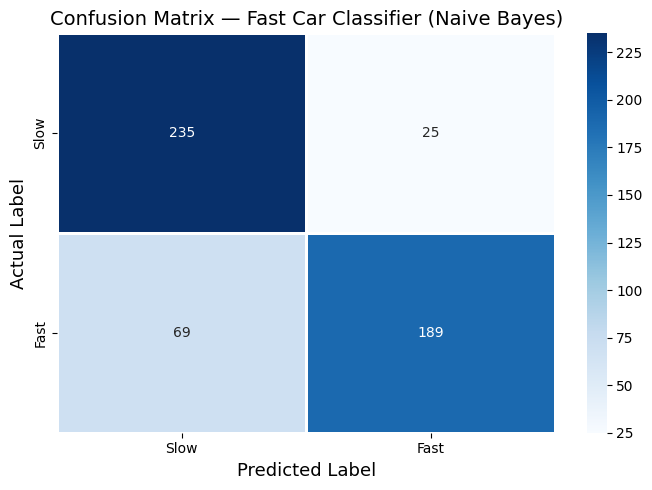

In [542]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Slow', 'Fast'], yticklabels=['Slow', 'Fast'],
            linewidths=1, ax=ax)
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('Actual Label', fontsize=13)
ax.set_title('Confusion Matrix — Fast Car Classifier (Naive Bayes)', fontsize=14)
plt.tight_layout()
plt.show()

##Predicted Probability of Being a Fast Car by Body Type
For each body type present in the feature set, this bar chart shows the average predicted probability of being a fast car — evaluated only on the test set. A dashed line at 0.5 marks the decision threshold. Body types above this line are predicted as fast on average; those below as slow.

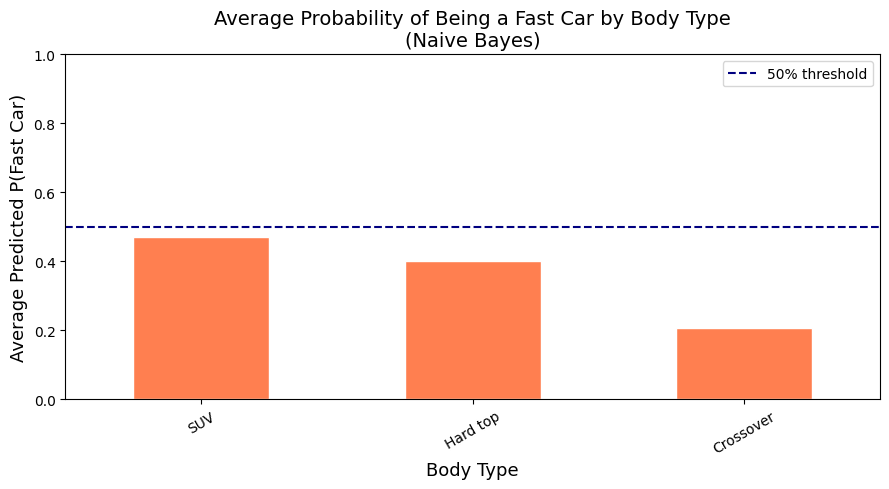

In [543]:
body_type_cols = [c for c in features if 'Kasa Tipi_' in c]

if body_type_cols:
    prob_by_body = {}
    for col in body_type_cols:
        mask = X_test[col] == 1
        if mask.sum() > 0:
            subset = X_test.loc[mask, features].fillna(0)
            proba = model.predict_proba(subset)[:, 1].mean()
            prob_by_body[col.replace('Kasa Tipi_', '')] = proba

    prob_df = pd.Series(prob_by_body).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(9, 5))
    prob_df.plot(kind='bar', ax=ax, color='coral', edgecolor='white')

    ax.set_xlabel('Body Type', fontsize=13)
    ax.set_ylabel('Average Predicted P(Fast Car)', fontsize=13)
    ax.set_title('Average Probability of Being a Fast Car by Body Type\n(Naive Bayes)', fontsize=14)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color='navy', linestyle='--', linewidth=1.5, label='50% threshold')
    ax.legend()
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()
else:
    print("No Kasa Tipi_ columns found in features. Adjust feature selection.")

##Hand-Crafted Demo Predictions
Pulls one actual fast car and one actual slow car from the test set by their index, then runs them through the trained model. Outputs the prediction label and the model's confidence percentage for each example. Since these rows come directly from `X_test`, no manual feature construction is needed

In [544]:
# Find a 'Fast' car and a 'Slow' car in your test set to use as demos
fast_example_index = y_test[y_test == 1].index[0]
slow_example_index = y_test[y_test == 0].index[0]

demo_indices = {"Realistic Fast Car": fast_example_index,
                "Realistic Slow Car": slow_example_index}

print("=== Automated Demo Predictions ===\n")
for name, idx in demo_indices.items():
    row = X_test.loc[[idx]]
    prob = model.predict_proba(row)[0][1]
    pred = model.predict(row)[0]

    print(f"{name} (Index {idx}):")
    print(f" -> Result: {'FAST' if pred == 1 else 'SLOW'}")
    print(f" -> Confidence: {prob*100:.2f}%\n")

=== Automated Demo Predictions ===

Realistic Fast Car (Index 1269):
 -> Result: FAST
 -> Confidence: 65.39%

Realistic Slow Car (Index 190):
 -> Result: SLOW
 -> Confidence: 22.69%



##Note
The model's primary limitation is the conditional independence assumption, which is known to be violated in this dataset. Despite this, Gaussian Naive Bayes often achieves competitive accuracy even when the assumption does not hold — a phenomenon sometimes called the Naive Bayes paradox. The results should be interpreted with this context in mind.